7.134405817990242e-20
0.003129793139490874
class: msp
[2.76056583e+07 8.28169749e+07 1.93239608e+08 4.14084875e+08
 8.55775408e+08 1.73915647e+09 3.50591861e+09 7.03944287e+09
 1.41064914e+10]
1e-06 s
class                          msp
P           0.003129793139490874 s
Pdot         7.134405817990242e-20
S1400      0.48279508260172005 mJy
duty                      0.013686
a1                             NaN
ecc                            NaN
P_orb                          NaN
A_red                          0.0
pos_err                   0.400194
Name: 0, dtype: object
1.377710535274716e-14
0.4771762857721153
class: canonical
[  181065.1591019    543195.47758197  1267456.11748948  2715977.40748038
  5613020.02928291 11407105.43749192 22995276.91656916 46171622.52342968
 92524324.33043976]
9.411082989740963e-05 s
class                   canonical
P            0.4771762857721153 s
Pdot        1.377710535274716e-14
S1400      0.8903943593250229 mJy
duty                     0.060589
a1      

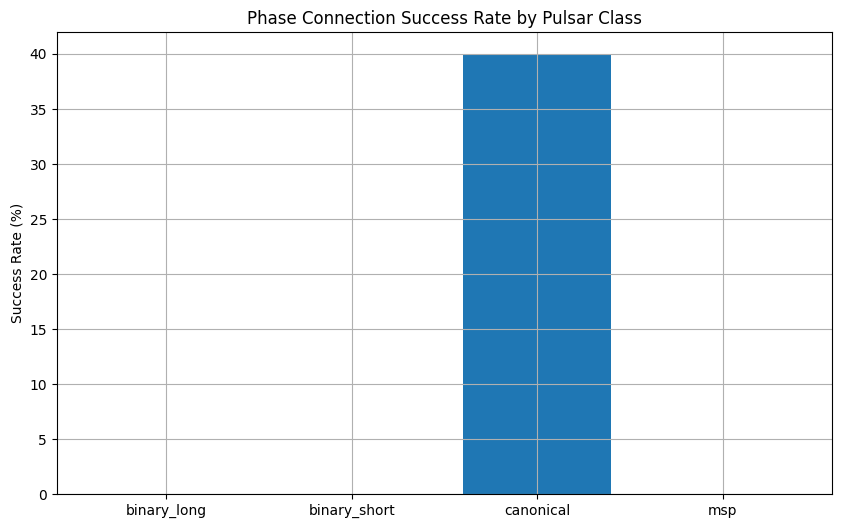

In [23]:
import numpy as np
import pandas as pd
from scipy.linalg import inv
from astropy import constants as const
from astropy import units as u
import matplotlib.pyplot as plt

# ========================
# Constants & Configuration
# ========================
class Config:
    SEFD = 2.5 * u.Jy            # System equivalent flux density
    BW = 600 * u.MHz             # Bandwidth
    T_INT = 660.0 * u.s          # Integration time
    N_POL = 2                    # Polarizations
    TOA_ERR_FLOOR = 1 * u.s*1e-6    # Minimum achievable TOA uncertainty
    C = const.c.to(u.m/u.s).value
    
    # Population parameters
    CLASS_PROBS = {
        "canonical": 0.6,
        "msp": 0.25,
        "binary_long": 0.1,
        "binary_short": 0.05
    }
    
    # Cadence strategy (days between epochs)
    CADENCE = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256], dtype=float)

# ========================
# Pulsar Population Model
# ========================
class PulsarGenerator:
    def __init__(self, n_pulsars):
        self.n = n_pulsars
        self.rng = np.random.default_rng(42)
        
    def generate(self):
        """Generate pulsar population with realistic parameters"""
        cls = self.rng.choice(list(Config.CLASS_PROBS.keys()),
                              p=list(Config.CLASS_PROBS.values()),
                              size=self.n)
        
        params = pd.DataFrame(index=range(self.n), columns=[
            "class", "P", "Pdot", "S1400", "duty", "a1", "ecc", "P_orb",
            "A_red", "pos_err"
        ])

        params["class"] = cls
        
        # Common parameters
        params["pos_err"] = self.rng.lognormal(np.log(0.5), 0.3, self.n) * u.arcsec
        params["A_red"] = 10**self.rng.normal(-23, 1.5, self.n) * u.s**1.5
        
        # Class-specific parameters
        for i in range(self.n):
            c = params.at[i, "class"]
            if c == "canonical":
                self._set_canonical(params, i)
            elif c == "msp":
                self._set_msp(params, i)
            else:
                self._set_binary(params, i)
                
        return params
    
    def _set_canonical(self, params, i):
        params.at[i, "P"] = 10**self.rng.normal(-0.3, 0.4) * u.s
        params.at[i, "Pdot"] = 10**self.rng.uniform(-15, -12) * u.s/u.s
        params.at[i, "S1400"] = 10**self.rng.normal(0.3, 0.6) * u.mJy
        params.at[i, "duty"] = self.rng.uniform(0.03, 0.07)
        
    def _set_msp(self, params, i):
        params.at[i, "P"] = 10**self.rng.normal(-2.3, 0.3) * u.s
        params.at[i, "Pdot"] = 10**self.rng.uniform(-21, -18) * u.s/u.s
        params.at[i, "S1400"] = 10**self.rng.normal(-0.3, 0.5) * u.mJy
        params.at[i, "duty"] = self.rng.uniform(0.01, 0.03)
        
    def _set_binary(self, params, i):
        params.at[i, "P"] = 10**self.rng.normal(-2.5, 0.5) * u.s
        params.at[i, "Pdot"] = 10**self.rng.uniform(-19, -16) * u.s/u.s
        params.at[i, "S1400"] = 10**self.rng.normal(-0.5, 0.6) * u.mJy
        params.at[i, "duty"] = self.rng.uniform(0.01, 0.03)
        
        # Binary parameters
        if params.at[i, "class"] == "binary_short":
            params.at[i, "P_orb"] = 10**self.rng.uniform(-1.5, 0) * u.hr
            params.at[i, "ecc"] = self.rng.uniform(0, 0.05)
            params.at[i, "a1"] = 10**self.rng.uniform(-3, -2) * u.lightsecond
        else:
            params.at[i, "P_orb"] = 10**self.rng.uniform(1, 3) * u.day
            params.at[i, "ecc"] = self.rng.beta(1, 3)
            params.at[i, "a1"] = 10**self.rng.uniform(-2, 0) * u.lightsecond

# ========================
# Noise & Timing Models
# ========================
class TimingModel:
    @staticmethod
    def compute_toa_uncertainty(pulsar):
        """Radiometer equation-based TOA uncertainty"""
        snr = (pulsar.S1400.to(u.Jy)/Config.SEFD) * \
              np.sqrt(Config.N_POL * Config.BW.to(u.Hz) * Config.T_INT) * \
              np.sqrt((pulsar.P - pulsar.duty*pulsar.P)/pulsar.P)
        return np.clip((pulsar.duty*pulsar.P/snr).to(u.s),
                       Config.TOA_ERR_FLOOR, None)
    
    @staticmethod
    def red_noise(t, A_red):
        """Red noise realization with PSD ∝ f^-4"""
        dt = np.diff(t, prepend=0)
        return A_red * np.cumsum(np.sqrt(dt) * np.random.randn(len(t)))
    
    @staticmethod
    def shklovskii_effect(pos_err, t_span, P):
        """Proper position error contribution (van Straten 2013)"""
        mu = (2*np.pi*u.rad/u.yr).to(u.rad/u.s)  # Proper motion assumption
        return (mu**2 * pos_err.to(u.rad) * P / const.c).decompose()
    
    @staticmethod
    def binary_delay(t, P_orb, a1, ecc):
        """Roemer delay with proper unit handling"""
        # Convert all to SI units
        t_sec = t * u.s if not isinstance(t, u.Quantity) else t.to(u.s)
        P_orb_sec = P_orb.to(u.s)
        a1_m = a1.to(u.m)
        
        # Dimensionless phase calculation
        phase = (2 * np.pi * t_sec / P_orb_sec).value  # Unitless for sin()
        
        # Calculate delay in seconds
        delay = (a1_m / const.c).to(u.s) * (np.sin(phase) + 0.5*ecc*np.sin(2*phase))
        return delay

# ========================
# Simulation Core
# ========================
class PulsarSurveySimulator:
    def __init__(self, cadence=Config.CADENCE):
        self.cadence = cadence * u.day
        self.obs_times = np.cumsum(self.cadence)
        
    def run(self, pulsars):
        results = []
        for _, psr in pulsars.iterrows():
            # Generate TOAs with noise
            toa_err = TimingModel.compute_toa_uncertainty(psr)
            phases = self._generate_phases(psr, toa_err)
            print(phases)
            print(toa_err)
            print(psr)
            # Fit timing model
            success = self._fit_timing_model(phases, psr, toa_err)
            results.append(success)
            
        return pd.Series(results)
    
    def _generate_phases(self, psr, toa_err):
        """Generate observed phases with all noise contributions"""
        t = self.obs_times.to(u.s).value
        print(psr.Pdot.value)
        print(psr.P.value)
        true_phase = t/psr.P.value + 0.5*psr.Pdot.value*(t**2)/psr.P.value
        
        # Add noise terms
        phase = true_phase.copy()
        phase += np.random.normal(0, toa_err.value/psr.P.value, len(t))
        phase += TimingModel.red_noise(t, psr.A_red)/psr.P.value
        print('class:', psr["class"])
        if psr["class"].startswith("binary"):
            delay = TimingModel.binary_delay(t, psr.P_orb, 
                                            psr.a1, psr.ecc)
            phase += delay.value/psr.P.value
            
        return phase
    
    def _fit_timing_model(self, phases, psr, toa_err):
        """Least-squares timing solution with covariance matrix"""
        t = self.obs_times.to(u.s).value
        X = np.column_stack([t, 0.5*t**2])
        
        # Convert scalar TOA error to array
        weights = (1/(toa_err.to(u.s).value**2)) * np.ones(len(t))  # Changed line
        W = np.diag(weights)  # Now works with array input
        
        try:
            # Solve weighted least squares
            cov = inv(X.T @ W @ X)
            params = cov @ X.T @ W @ phases
            residuals = phases - X @ params
            
            # Check convergence
            chi2 = np.sum((residuals * np.diag(W)**0.5)**2)
            if chi2/len(phases) > 2.0:
                return False  # Poor fit
            
            # Check parameter significance
            sig_P = np.sqrt(cov[0,0])
            sig_Pdot = np.sqrt(cov[1,1])
            return (psr.Pdot/sig_Pdot > 3), chi2 < len(phases) + 2*np.sqrt(2*len(phases))
        
        except np.linalg.LinAlgError:
            return False

# ========================
# Analysis & Visualization
# ========================
#if __name__ == "__main__":
# Generate population
generator = PulsarGenerator(n_pulsars=1000)
pulsars = generator.generate()

# Run simulation
simulator = PulsarSurveySimulator()
results = simulator.run(pulsars)

# Assign results to DataFrame
pulsars["success"] = results

# Analyze results
def success_to_bool(val):
    if isinstance(val, tuple):
        return all(val)
    return bool(val)

pulsars["success_bool"] = pulsars["success"].apply(success_to_bool)
report = pulsars.groupby("class").agg(
    N=("success_bool", "count"),
    success_rate=("success_bool", "mean"),
    mean_Pdot=("Pdot", "mean")
)
print(report)

# Plot success rates
plt.figure(figsize=(10,6))
plt.bar(report.index, report["success_rate"]*100)
plt.ylabel("Success Rate (%)")
plt.title("Phase Connection Success Rate by Pulsar Class")
plt.grid(True)
plt.show()

In [20]:
# Test binary delay calculation
a1 = 1 * u.lightsecond  # ~0.002 AU
P_orb = 2 * u.hr
ecc = 0.1
t = np.array([0, 0.5, 1]) * P_orb.to(u.s)

delay = TimingModel.binary_delay(t, P_orb, a1, ecc)
print(f"Binary delays: {delay}")  # Should be ~[0, ~1000, 0] ms

Binary delays: [ 0.00000000e+00  1.10218212e-16 -2.69422296e-16] s


In [26]:
import astropy.units as u
l = 1*u.lightsecond

In [13]:
rng = np.random.default_rng(42)

lsg = 10**rng.uniform(-3, -2) * u.lightsecond

print(lsg.value)

0.0059423201813949824
